In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import classification_report


In [ ]:
class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean = None
        self.components = None
        
    def fit_transform(self, X):
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvectors = eigenvectors[:, sorted_idx]
        eigenvalues = eigenvalues[sorted_idx]
        
        self.components = eigenvectors[:, :self.n_components]
        
        self.eigenvalues = eigenvalues
        self.total_variance = np.sum(eigenvalues)
        
        return np.dot(X_centered, self.components)
    
    def get_information_loss(self):
        explained_variance = np.sum(self.eigenvalues[:self.n_components])
        loss = 1 - (explained_variance / self.total_variance)
        return loss * 100

In [10]:
data = pd.read_csv('../lessons/Dry_Bean_Dataset.csv', delimiter=';', decimal=',')
print(data.columns.tolist())
data = data.dropna(axis=1, how='all')  
data.fillna(data.mean(numeric_only=True), inplace=True)
X = data.drop(['Class'], axis=1).values
le = LabelEncoder()
y = le.fit_transform(data['Class'].values)


print(f"Признаков: {X.shape[1]}, Объектов: {X.shape[0]}")

print(pd.Series(y).value_counts())



scaler = StandardScaler()
X = scaler.fit_transform(X)


['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4', 'Class']
Признаков: 16, Объектов: 13611
3    3546
6    2636
5    2027
4    1928
2    1630
0    1322
1     522
Name: count, dtype: int64


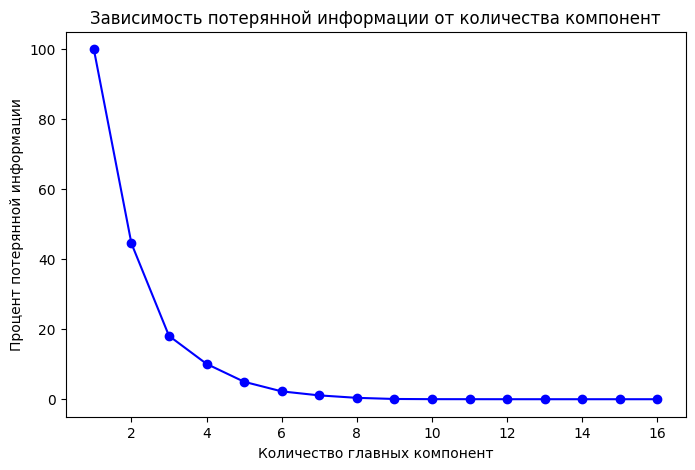

In [11]:
loss_info = []

for i in range(X.shape[1]):
    pca = PCA(i)
    X_i = pca.fit_transform(X)
    loss_info.append(pca.get_information_loss())


plt.figure(figsize=(8, 5))

plt.plot(range(1, len(loss_info) + 1), loss_info, marker='o', color='b', linestyle='-')

plt.xlabel('Количество главных компонент')
plt.ylabel('Процент потерянной информации')
plt.title('Зависимость потерянной информации от количества компонент')
plt.show()

In [14]:
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X) 

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

print(f"Признаков: {X_pca.shape[1]}, Объектов: {X_pca.shape[0]}")


Признаков: 6, Объектов: 13611


In [13]:
model = DecisionTreeClassifier(
    criterion='log_loss',             
    splitter='best',              
    max_depth=10,               
    min_samples_split=2,           
    min_samples_leaf=1,           
    min_weight_fraction_leaf=0.0,  
    max_features=None,            
    random_state=None,            
    max_leaf_nodes=None,           
    min_impurity_decrease=0.0,     
    class_weight='balanced',             
    ccp_alpha=0.0         
)
model.fit(X_train_pca, y_train_pca)

y_pred = model.predict(X_test_pca)

accuracy = classification_report(y_test_pca, y_pred)
print(accuracy)

              precision    recall  f1-score   support

           0       0.93      0.87      0.90       261
           1       0.99      0.99      0.99       117
           2       0.91      0.95      0.93       317
           3       0.90      0.88      0.89       671
           4       0.96      0.93      0.95       408
           5       0.95      0.93      0.94       413
           6       0.81      0.86      0.83       536

    accuracy                           0.90      2723
   macro avg       0.92      0.92      0.92      2723
weighted avg       0.91      0.90      0.90      2723

